# Validating the Christoffel module using the GaAs elastic tensor standard

We demonstrate the functionality of the Christoffel module by applying it to the elastic tensor of gallium arsenide (GaAs). This elastic tensor is also employed in other codes with comparable capabilities, including AWESoMe (Muñoz-Santiburcio et al., 2015) and Christoffel (Jaeken & Cottenier, 2016). This makes it ideal for comparing and testing results.

**References**

Muñoz-Santiburcio, D., Hernández-Laguna, A., Soto, J.I., 2015. AWESoMe: A code for the calculation of phase and group velocities of acoustic waves in homogeneous solids. Computer Physics Communications 192, 272–277. https://doi.org/10.1016/j.cpc.2015.02.024

Jaeken, J.W., Cottenier, S., 2016. Solving the Christoffel equation: Phase and group velocities. Computer Physics Communications 207, 445–451. https://doi.org/10.1016/j.cpc.2016.06.014


In [53]:
import os
import sys

import numpy as np
import matplotlib.pyplot as plt

# Make the pyrockwave package importable from the notebooks/ folder
sys.path.insert(0, os.path.join("..", "src"))

# PyRockWave imports
from pyrockwave.christoffel import phase_seismic_properties, full_seismic_properties
from pyrockwave.utils.coordinates import equispaced_S2_grid, sph2cart, cart2sph
import pyrockwave.utils.tensor_tools as tt

## Input data

The data required to estimate the seismic properties in any direction of a given material using the Christoffel equation are the density in g/cm3 and the stiffness tensor of the material in GPa.

In [54]:
# set the elastic tensor and density of gallium arsenide (GaAs)
Cij_GaAs = np.array([[118.8,  53.8,  53.8,   0. ,   0. ,   0. ],
                     [ 53.8, 118.8,  53.8,   0. ,   0. ,   0. ],
                     [ 53.8,  53.8, 118.8,   0. ,   0. ,   0. ],
                     [  0. ,   0. ,   0. ,  59.4,   0. ,   0. ],
                     [  0. ,   0. ,   0. ,   0. ,  59.4,   0. ],
                     [  0. ,   0. ,   0. ,   0. ,   0. ,  59.4]])

density_GaAs = 5.307

## Step 0: create an array with wave vectors

For most materials, the seismic properties are anisotropic, i.e. they depend on the direction. Accordingly, the Christoffel equation must be solved for each propagation direction of interest, and we must first define these directions, denoted as wave vectors or $\vec{q}$. Wave vectors can be defined in spherical coordinates (polar and azimuthal angles) or in Cartesian coordinates ($x, y, z$) normalised to the unit sphere (i.e. vectors of size 1 or unit vectors). Cartesian coordinates are typically used for calculations. In this case we will use the following procedure:

- Create equispaced wavevectors in spherical coordinates
- Convert from spherical to 3D Cartesian unit vectors
- Store the wave vectors in a single array with three columns ($x, y, z$) for calculations

In [55]:
azimuth_angs, polar_angs = equispaced_S2_grid(num_points=9289, degrees=False)

In [56]:
azimuth_angs.max(), polar_angs.max()

(np.float64(6.282769944890816), np.float64(3.141592653589793))

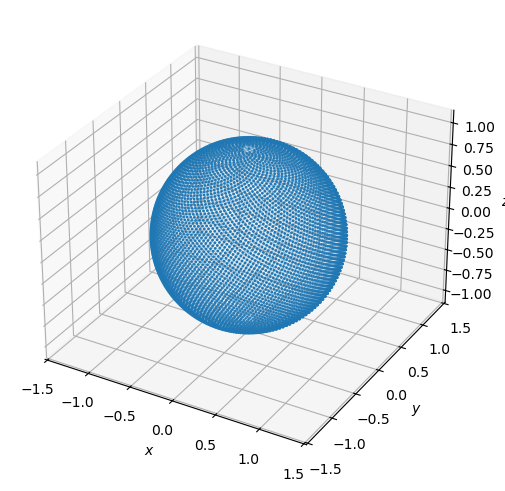

In [57]:
# test
# convert from spherical to 3d cartesian
x, y, z = sph2cart(
    azimuth_rad=azimuth_angs,
    polar_rad=polar_angs
)

# plot to test
fig, ax = plt.subplots(subplot_kw={"projection": "3d"}, constrained_layout=True)
ax.scatter(x, y, z, s=1)
ax.axis('equal')
_ = ax.set_xlabel(r'$x$'), ax.set_ylabel(r'$y$'), ax.set_zlabel(r'$z$')

In [58]:
velocities, _ = phase_seismic_properties(
    Cij=Cij_GaAs,
    density_gcm3=density_GaAs,
    azimuths_deg=np.rad2deg(azimuth_angs),
    polar_deg=np.rad2deg(polar_angs)
)

In [59]:
velocities

,azimuths_deg,polar_deg,qx,qy,qz,Vs2_phase_kms,Vs1_phase_kms,Vp_phase_kms,VpVs1,VpVs2,SWS_perc,dVs2_perc,dVs1_perc,dVp_perc
0,0.000000,0.000000,0.000000e+00,0.000000,1.000000,3.345559,3.345559,4.731335,1.414214,1.414214,0.000000e+00,12.861979,12.861979,-7.096926
1,0.000000,3.757067,6.552620e-02,0.000000,0.997851,3.326893,3.345559,4.744479,1.418142,1.426099,5.595024e-01,12.232275,12.861979,-6.838835
2,222.492236,3.940516,-5.067255e-02,-0.046420,0.997636,3.328557,3.342014,4.745809,1.420045,1.425786,4.034605e-01,12.288437,12.742392,-6.812710
3,84.984472,4.115808,6.274775e-03,0.071498,0.997421,3.323316,3.345460,4.747054,1.418954,1.428409,6.641130e-01,12.111630,12.858658,-6.788271
4,307.476708,4.283946,4.544996e-02,-0.059281,0.997206,3.325214,3.341682,4.748387,1.420957,1.427994,4.940316e-01,12.175632,12.731188,-6.762103
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9284,75.426323,175.716054,1.879619e-02,0.072296,-0.997206,3.322237,3.344699,4.748346,1.419663,1.429262,6.738260e-01,12.075211,12.832956,-6.762895
9285,297.918559,175.884192,3.360510e-02,-0.063419,-0.997421,3.325670,3.343074,4.747086,1.419976,1.427407,5.219567e-01,12.191042,12.778163,-6.787634
9286,160.410795,176.059484,-6.474325e-02,0.023040,-0.997636,3.326295,3.344301,4.745784,1.419066,1.426748,5.398419e-01,12.212125,12.819532,-6.813197
9287,22.903031,176.242933,6.036043e-02,0.025501,-0.997851,3.328379,3.344055,4.744497,1.418786,1.425468,4.698643e-01,12.282421,12.811238,-6.838486


In [60]:
velocities.describe()

,azimuths_deg,polar_deg,qx,qy,qz,Vs2_phase_kms,Vs1_phase_kms,Vp_phase_kms,VpVs1,VpVs2,SWS_perc,dVs2_perc,dVs1_perc,dVp_perc
count,9289.000000,9289.000000,9289.000000,9289.000000,9.289000e+03,9289.000000,9289.000000,9289.000000,9289.000000,9289.000000,9289.000000,9289.000000,9289.000000,9289.000000
mean,179.938661,90.000000,0.000006,0.000001,0.000000e+00,2.769934,3.218916,5.162072,1.607901,1.878041,15.177267,-6.556659,8.589692,1.360893
std,103.959816,39.031016,0.577908,0.577907,5.763273e-01,0.215136,0.129746,0.164361,0.110583,0.187587,7.504398,7.257575,4.376970,3.227335
min,0.000000,0.000000,-0.999859,-0.999758,-1.000000e+00,2.474759,2.797561,4.731335,1.414214,1.414214,0.000000,-16.514335,-5.624669,-7.096926
25%,89.922118,60.063963,-0.500652,-0.501503,-4.990329e-01,2.610774,3.142658,5.060137,1.531537,1.749917,9.813336,-11.925906,6.017150,-0.640670
50%,179.945049,90.000000,0.000000,0.000000,6.123234e-17,2.707888,3.265892,5.208735,1.584787,1.946265,14.314725,-8.649769,10.174411,2.277154
75%,269.929473,119.936037,0.500901,0.499333,4.990329e-01,2.894561,3.326934,5.283738,1.677271,2.023454,21.081398,-2.352382,12.233685,3.749903
max,359.976201,180.000000,0.999810,0.999877,1.000000e+00,3.345559,3.345559,5.398501,1.929717,2.117268,29.918842,12.861979,12.861979,6.003358


In [61]:
# max and min seismic velocities
print(f"Vp. max: {velocities["Vp_phase_kms"].max():.3f}, min: {velocities["Vp_phase_kms"].min():.3f}")
print(f"Vs1. max: {velocities["Vs1_phase_kms"].max():.3f}, min: {velocities["Vs1_phase_kms"].min():.3f}")
print(f"Vs2. max: {velocities["Vs2_phase_kms"].max():.3f}, min: {velocities["Vs2_phase_kms"].min():.3f}")

Vp. max: 5.399, min: 4.731
Vs1. max: 3.346, min: 2.798
Vs2. max: 3.346, min: 2.475


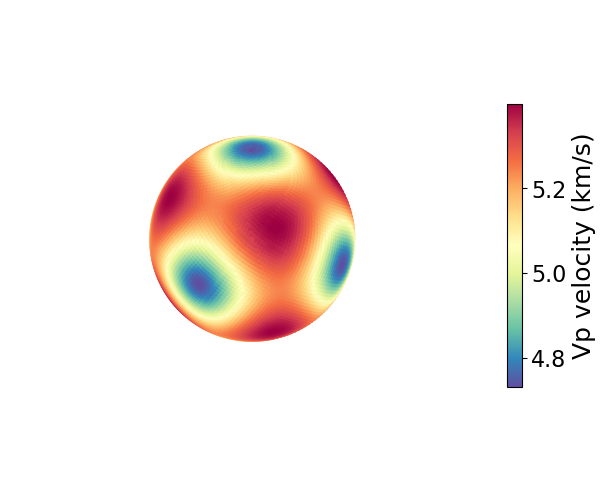

In [62]:
# plot to test
fig1, ax = plt.subplots(subplot_kw={"projection": "3d"}, constrained_layout=True)

speed = ax.scatter(x, y, z, c=velocities["Vp_phase_kms"], cmap='Spectral_r')
ax.axis("off")
ax.axis('equal')  # Set an equal aspect ratio

# add color bar
cbar = fig1.colorbar(speed, ax=ax, shrink=0.6, location='right')
cbar.set_label('Vp velocity (km/s)', fontsize=18)
cbar.ax.tick_params(labelsize=16)

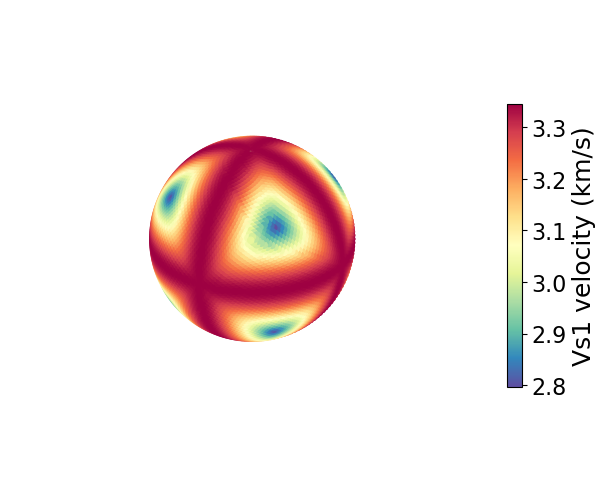

In [63]:
# plot to test
fig2, ax = plt.subplots(subplot_kw={"projection": "3d"}, constrained_layout=True)

speed = ax.scatter(x, y, z, c=velocities["Vs1_phase_kms"], cmap='Spectral_r')
ax.axis("off")
ax.axis('equal')  # Set an equal aspect ratio

# add color bar
cbar = fig2.colorbar(speed, ax=ax, shrink=0.6, location='right')
cbar.set_label('Vs1 velocity (km/s)', fontsize=18)
cbar.ax.tick_params(labelsize=16)

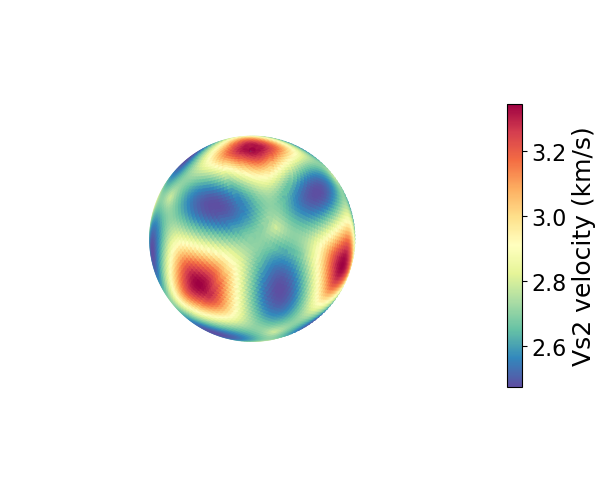

In [64]:
# plot to test
fig3, ax = plt.subplots(subplot_kw={"projection": "3d"}, constrained_layout=True)

speed = ax.scatter(x, y, z, c=velocities["Vs2_phase_kms"], cmap='Spectral_r')
ax.axis("off")
ax.axis('equal')  # Set an equal aspect ratio

# add color bar
cbar = fig3.colorbar(speed, ax=ax, shrink=0.6, location='right')
cbar.set_label('Vs2 velocity (km/s)', fontsize=18)
cbar.ax.tick_params(labelsize=16)

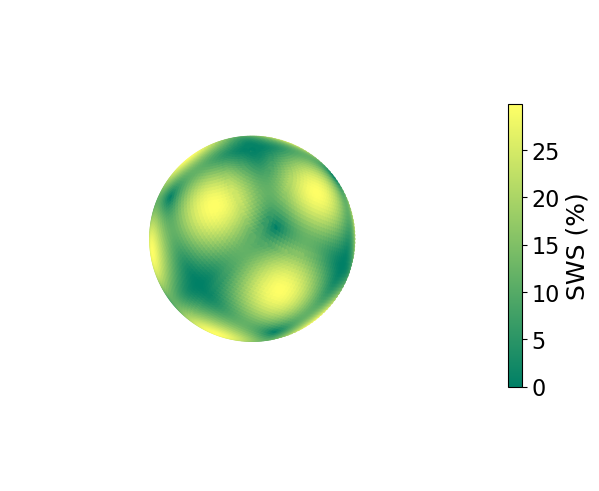

In [65]:
fig4, ax = plt.subplots(subplot_kw={"projection": "3d"}, constrained_layout=True)

speed = ax.scatter(x, y, z, c=velocities["SWS_perc"], cmap='summer')
ax.axis("off")
ax.axis('equal')  # Set an equal aspect ratio

# add color bar
cbar = fig4.colorbar(speed, ax=ax, shrink=0.6, location='right')
cbar.set_label('SWS (%)', fontsize=18)
cbar.ax.tick_params(labelsize=16)

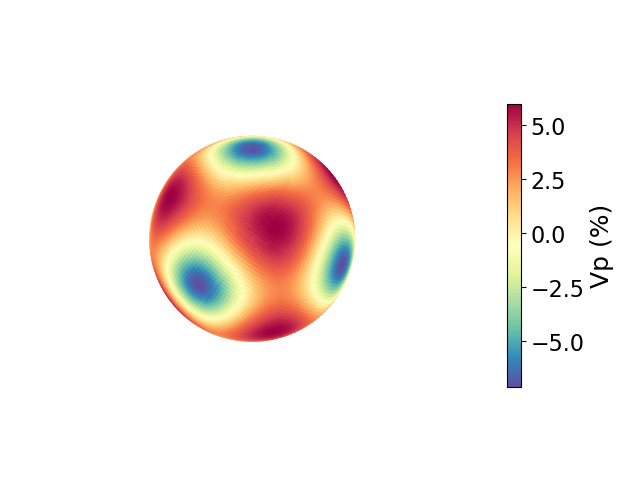

In [66]:
fig5, ax = plt.subplots(subplot_kw={"projection": "3d"}, constrained_layout=True)

speed = ax.scatter(x, y, z, c=velocities["dVp_perc"], cmap='Spectral_r')
ax.axis("off")
ax.axis('equal')  # Set an equal aspect ratio

# add color bar
cbar = fig5.colorbar(speed, ax=ax, shrink=0.6, location='right')
cbar.set_label('Vp (%)', fontsize=18)
cbar.ax.tick_params(labelsize=16)

## Polarizations

In [67]:
azi, polar = equispaced_S2_grid(num_points=300, degrees=False, hemisphere='upper')

# convert from spherical to 3d cartesian
qx, qy, qz = sph2cart(azimuth_rad=azi, polar_rad=polar)

In [68]:
_, polarization = phase_seismic_properties(
    Cij=Cij_GaAs,
    density_gcm3=density_GaAs,
    azimuths_deg=np.rad2deg(azi),
    polar_deg=np.rad2deg(polar),
)

In [69]:
wavevectors = np.column_stack((qx, qy, qz))

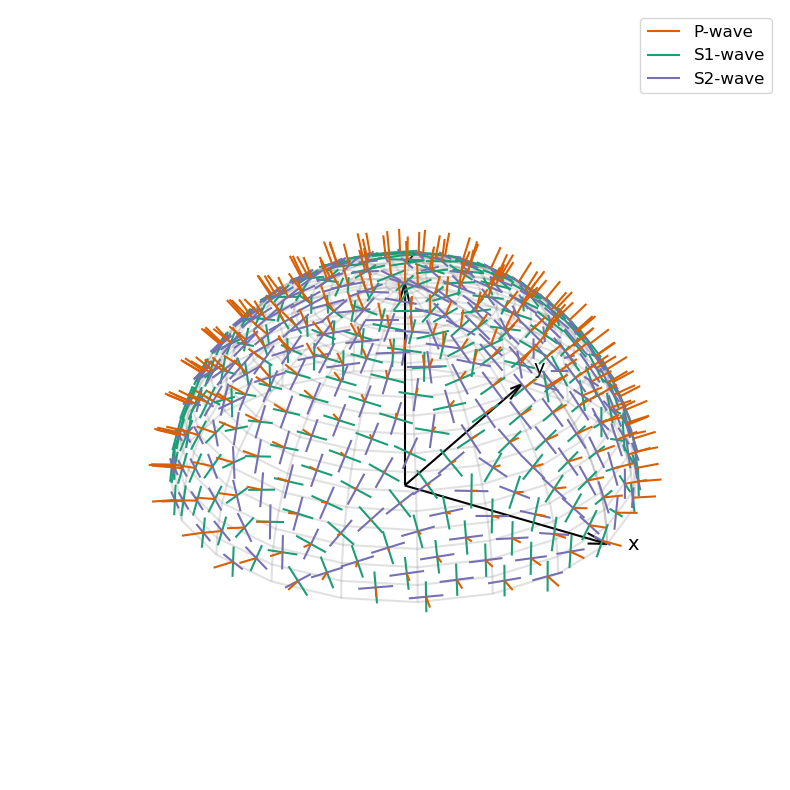

In [70]:
fig6, ax = plt.subplots(figsize=(10, 10), subplot_kw={"projection": "3d"})

# Plot unit sphere (upper hemisphere, matching the wavevector grid)
u = np.linspace(0, 2 * np.pi, 20)
v = np.linspace(0, np.pi / 2, 20)
x = np.outer(np.cos(u), np.sin(v))
y = np.outer(np.sin(u), np.sin(v))
z = np.outer(np.ones(np.size(u)), np.cos(v))
ax.plot_wireframe(x, y, z, color='dimgray', alpha=0.2)

# Plot coordinate axes, labelled at their tips
origin = [0, 0, 0]
for axis_dir, name in zip([(1, 0, 0), (0, 1, 0), (0, 0, 1)], ['x', 'y', 'z']):
    ax.quiver(*origin, *axis_dir, color='black', normalize=True, arrow_length_ratio=0.1)
    ax.text(*(1.1 * np.array(axis_dir)), name, fontsize=14)

# P-wave polarizations, sign-flipped to point outward
dots = np.einsum('ij,ij->i', polarization[:, 2], wavevectors)
p_polarization = polarization[:, 2] * np.where(dots < 0, -1.0, 1.0)[:, None]

ax.quiver(*wavevectors.T, *p_polarization.T, color='#d95f02', length=0.10,
          arrow_length_ratio=0, label='P-wave')

# S-wave polarizations (unsigned, so centred on the surface point)
ax.quiver(*wavevectors.T, *polarization[:, 1].T, color='#1b9e77',
          pivot='middle', length=0.15, arrow_length_ratio=0, label='S1-wave')
ax.quiver(*wavevectors.T, *polarization[:, 0].T, color='#7570b3',
          pivot='middle', length=0.15, arrow_length_ratio=0, label='S2-wave')

# Prettify the figure
ax.set_proj_type('ortho')  # orthographic view preserves angles
ax.set_aspect('equal')
ax.axis('off')
ax.legend(loc='upper right', fontsize=12)
# ax.view_init(elev=90, azim=180, roll=0)

In [71]:
def prepare_quiver_data(
    wavevectors: np.ndarray,
    eigenvectors: np.ndarray,
) -> tuple[np.ndarray, np.ndarray, np.ndarray, np.ndarray]:
    """
    Project 3D polarization vectors onto pole-figure (polar plot) coordinates.

    Positions use the equal-area (Schmidt) mapping r = sqrt(2)*sin(polar/2),
    which maps the upper hemisphere onto the unit disc. The vector components
    are the xy-projection of each polarization vector; the z-component is
    deliberately discarded, so vectors polarized near-vertically plot as
    short segments.

    The intended polar axes use theta zero at north and clockwise direction,
    i.e. the screen mapping (x, y) -> (y, x). Matplotlib's quiver keeps U/V
    in fixed screen coordinates (it does not apply the theta transforms to
    the arrow components), so the xy components are swapped here to remain
    consistent with the axis labels.

    Parameters
    ----------
    wavevectors : numpy.ndarray of shape (n, 3)
        Unit wavevectors on the upper hemisphere.
    eigenvectors : numpy.ndarray of shape (n, 3)
        Polarization vectors of a single wave mode, one per wavevector.

    Returns
    -------
    tuple[numpy.ndarray, numpy.ndarray, numpy.ndarray, numpy.ndarray]
        theta, r positions and U, V arrow components for ax.quiver on a
        polar axes with theta zero at 'N' and clockwise direction.
    """
    theta = np.arctan2(wavevectors[:, 1], wavevectors[:, 0])
    polar_ang = np.arccos(np.clip(wavevectors[:, 2], -1.0, 1.0))
    r = np.sqrt(2.0) * np.sin(polar_ang / 2.0)  # equal-area (Schmidt)

    # swap xy components to compensate for the (x, y) -> (y, x) screen mapping
    U = eigenvectors[:, 1]
    V = eigenvectors[:, 0]

    return theta, r, U, V


def plot_polarization_map(
    wavevectors: np.ndarray,
    eigenvectors: np.ndarray,
    color: str,
    title: str,
) -> tuple[plt.Figure, plt.Axes]:
    """
    Plot the xy-projection of polarization vectors on an equal-area
    pole figure of the upper hemisphere, with x pointing north.

    Parameters
    ----------
    wavevectors : numpy.ndarray of shape (n, 3)
        Unit wavevectors on the upper hemisphere.
    eigenvectors : numpy.ndarray of shape (n, 3)
        Polarization vectors of a single wave mode, one per wavevector.
    color : str
        Matplotlib color for the vectors.
    title : str
        Figure title.

    Returns
    -------
    tuple[matplotlib.figure.Figure, matplotlib.axes.Axes]
        The figure and its polar axes.
    """
    theta, r, U, V = prepare_quiver_data(wavevectors, eigenvectors)

    fig, ax = plt.subplots(subplot_kw=dict(projection="polar"), constrained_layout=True)

    ax.set_theta_direction(-1)
    ax.set_theta_zero_location("N")
    ax.set_xticks(np.arange(0, 2 * np.pi, np.pi / 4))
    ax.set_xticklabels(["x", "45°", "y", "45°", "-x", "45°", "-y", "45°"], fontsize=14)
    ax.set_yticks([])

    # pivot='middle' with headwidth=0 draws centred segments, so the
    # arbitrary sign of the eigenvectors does not matter
    ax.quiver(
        theta,  # vector position: angle
        r,      # vector position: radius
        U,      # x-component of the vector (screen frame)
        V,      # y-component of the vector (screen frame)
        color=color,
        pivot="middle",
        scale=13,
        headwidth=0,
    )
    ax.set_title(title, fontsize=15)

    return fig, ax

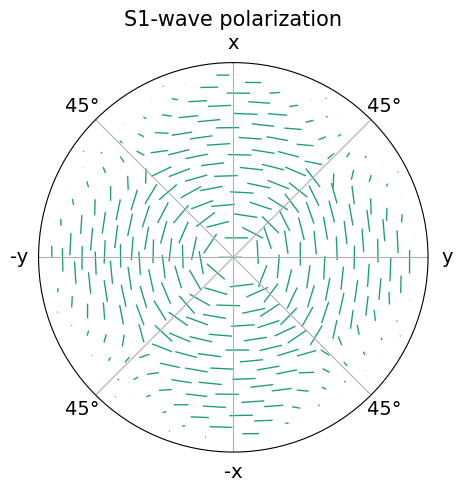

In [72]:
fig7, ax7 = plot_polarization_map(
    wavevectors, polarization[:, 1], color="#1b9e77", title="S1-wave polarization"
)

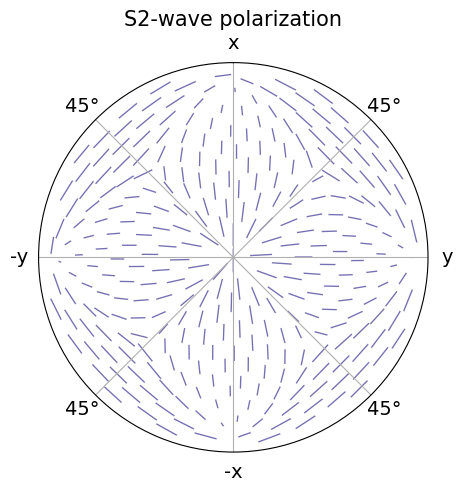

In [74]:
fig8, ax8 = plot_polarization_map(
    wavevectors, polarization[:, 0], color="#7570b3", title="S2-wave polarization"
)